In [1]:
# -*- coding: utf-8 -*-
from __future__ import annotations   # <-- 무조건 최상단

from DATA.stock_invest_function import *
import pandas as pd
import numpy as np
import matplotlib
import pymysql
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from dateutil.relativedelta import relativedelta
import warnings
warnings.filterwarnings("ignore")

matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False


In [2]:
db_info = {
    'user': 'stox7412',         # 예: 'root'
    'password': 'Apt106503!~', # 예: '1234'
    # 'host' : '192.168.0.230',
    'host': get_db_host(),         # 예: 'localhost' 또는 IP
    'port': 3307,              # 기본 포트는 보통 3306
    'database': 'investar'        # 예: 'trade_data'
}

# ====== 0) DB 연결 ======
def make_engine(db_info: dict):
    url = (
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}"
        f"@{db_info['host']}:{int(db_info['port'])}/{db_info['database']}?charset=utf8mb4"
    )
    return create_engine(
        url,
        pool_pre_ping=True,
        pool_recycle=1800,
        connect_args={
            "connect_timeout": 10,
            "read_timeout": 60,
            "write_timeout": 60,
        },
    )

engine = make_engine(db_info)

TABLE_NAME = "korea_monthly_trade_forecast_v2"

def make_pivot_from_trade_forecast_db(
    engine,
    forecast_dates: list,
    indicator: str,
    table_name: str = TABLE_NAME,
    aggfunc: str = "last"   # 중복 시 처리: "last" / "sum" 등
) -> pd.DataFrame:
    """
    forecast_dates(리스트) + indicator 조건으로 DB에서 데이터 조회 후
    index=date, columns=hs_code, values=value pivot 생성
    """

    if not forecast_dates:
        raise ValueError("forecast_dates 리스트가 비어 있습니다.")

    # MySQL IN 절용 placeholder 생성
    placeholders = ", ".join([f":d{i}" for i in range(len(forecast_dates))])
    params = {f"d{i}": forecast_dates[i] for i in range(len(forecast_dates))}
    params["indicator"] = indicator

    sql = text(f"""
        SELECT date, hs_code, value
        FROM {table_name}
        WHERE forecast_date IN ({placeholders})
          AND indicator = :indicator
    """)

    with engine.connect() as conn:
        df = pd.read_sql(sql, conn, params=params)

    if df.empty:
        raise ValueError("조건에 해당하는 데이터가 없습니다. forecast_dates/indicator를 확인하세요.")

    # 타입 정리
    df["date"] = pd.to_datetime(df["date"])
    df["hs_code"] = df["hs_code"].astype(str)

    # pivot
    pivot_df = (
        df.pivot_table(
            index="date",
            columns="hs_code",
            values="value",
            aggfunc=aggfunc  # 중복 시 마지막 값/합계 등 선택
        )
        .sort_index()
    )

    return pivot_df

import pandas as pd



# ====== 1) hs_code별 피벗 테이블 ======
def get_pivot_by_hscode(
    engine,
    hs_code: str,
    table: str = "korea_monthly_trade_forecast_v2",
    indicators: list[str] | None = None,
    use_latest_forecast_date: bool = True,
) -> pd.DataFrame:
    """
    - hs_code의 모든 row를 불러와서
      index=date, columns=indicator, values=value 형태의 피벗을 만듭니다.
    - 동일 key(date, hs_code, indicator)에 여러 행이 있으면 forecast_date가 최신인 것만 사용합니다.
    - indicators가 주어지면 해당 indicator만 포함합니다.
    """
    params = {"hs_code": hs_code}

    # 최신 forecast_date 선별 서브쿼리
    latest_join = ""
    if use_latest_forecast_date:
        latest_join = f"""
            JOIN (
                SELECT date, hs_code, indicator, MAX(forecast_date) AS max_fd
                FROM {table}
                GROUP BY date, hs_code, indicator
            ) L
              ON T.date = L.date AND T.hs_code = L.hs_code
             AND T.indicator = L.indicator AND T.forecast_date = L.max_fd
        """

    # indicator 필터
    ind_filter = ""
    if indicators:
        # 안전한 바인딩을 위해 IN (:i0, :i1, ...)
        in_keys = []
        for i, ind in enumerate(indicators):
            key = f"i{i}"
            in_keys.append(f":{key}")
            params[key] = ind
        ind_filter = f"AND T.indicator IN ({', '.join(in_keys)})"

    sql = text(f"""
        SELECT
            CAST(T.date AS DATE) AS date,
            T.hs_code,
            T.indicator,
            T.value
        FROM {table} T
        {latest_join}
        WHERE T.hs_code = :hs_code
        {ind_filter}
        ORDER BY date ASC
    """)
    df = pd.read_sql(sql, engine, params=params)
    if df.empty:
        return pd.DataFrame()

    df["date"] = pd.to_datetime(df["date"])
    pv = df.pivot_table(index="date", columns="indicator", values="value", aggfunc="last").sort_index()
    pv.index.name = "date"
    return pv


# ====== 2) 두 날짜 사이 기간 변화 (절대/증감률) ======
def get_period_change(
    engine,
    date1: str,
    date2: str,
    hs_code: str,
    indicator: str,
    table: str = "korea_monthly_trade_forecast_v2",
    use_latest_forecast_date: bool = True,
) -> dict:
    """
    - (date1, date2, hs_code, indicator)의 value를 비교해 절대/증감률 반환
    - 한쪽 날짜가 없어도 안전하게 처리하고, 어떤 날짜가 누락인지 note로 알려줍니다.
    """
    params = {"hs_code": hs_code, "indicator": indicator, "d1": date1, "d2": date2}

    latest_join = ""
    if use_latest_forecast_date:
        latest_join = f"""
            JOIN (
                SELECT date, hs_code, indicator, MAX(forecast_date) AS max_fd
                FROM {table}
                GROUP BY date, hs_code, indicator
            ) L
              ON T.date = L.date AND T.hs_code = L.hs_code
             AND T.indicator = L.indicator AND T.forecast_date = L.max_fd
        """

    sql = text(f"""
        SELECT CAST(T.date AS DATE) AS date, T.value
        FROM {table} T
        {latest_join}
        WHERE T.hs_code   = :hs_code
          AND T.indicator = :indicator
          AND T.date IN (:d1, :d2)
        ORDER BY T.date
    """)
    df = pd.read_sql(sql, engine, params=params)

    # 안전 처리: 인덱스로 바꿔 dict처럼 조회
    out = {
        "hs_code": hs_code,
        "indicator": indicator,
        "date1": date1,
        "date2": date2,
        "value_date1": None,
        "value_date2": None,
        "abs_change": None,
        "pct_change": None,
        "note": None,
    }

    if df.empty:
        out["note"] = "두 날짜 모두 조회되지 않았습니다."
        return out

    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    s = df.set_index("date")["value"]

    d1 = pd.to_datetime(date1).normalize()
    d2 = pd.to_datetime(date2).normalize()

    v1 = s.get(d1, None)
    v2 = s.get(d2, None)

    out["value_date1"] = float(v1) if v1 is not None else None
    out["value_date2"] = float(v2) if v2 is not None else None

    if (v1 is None) and (v2 is None):
        out["note"] = "두 날짜 모두 누락되었습니다."
        return out
    if v1 is None:
        out["note"] = f"{date1} 값이 없습니다."
        return out
    if v2 is None:
        out["note"] = f"{date2} 값이 없습니다."
        return out

    abs_chg = float(v2) - float(v1)
    pct_chg = None if float(v1) == 0 else abs_chg / float(v1)

    out["abs_change"] = abs_chg
    out["pct_change"] = pct_chg
    return out


# ====== 3) 12개월 YoY 성장률로 hs_code 랭킹 ======
def rank_hscodes_by_12m_yoy(
    engine,
    indicator: str,
    top_n: int = 10,
    as_of: str | None = None,  # 기준 월(없으면 테이블의 최신 월)
    table: str = "korea_monthly_trade_forecast_v2",
    use_latest_forecast_date: bool = True,
    drop_nonpositive_baseline: bool = False,  # 전년 값<=0이면 제외할지 옵션
) -> pd.DataFrame:
    """
    - 주어진 indicator에 대해 hs_code별로 최근(as_of) 월과 전년동월(as_of-12M)의 값을 비교해 YoY(%) 계산.
    - YoY = (value_t / value_t_12 - 1)
    - 기준월(as_of)이 None이면 테이블의 **최신 월**(전체 데이터 기준) 사용.
    - 결과: columns=[hs_code, as_of, prev_date, value_t, value_t_12, yoy_pct], yoy_pct 기준 내림차순 정렬 후 상위 top_n 반환.
    """
    # 3-1) 우선 해당 indicator의 전체 데이터(최신 forecast_date만) 로드
    latest_join = ""
    if use_latest_forecast_date:
        latest_join = f"""
            JOIN (
                SELECT date, hs_code, indicator, MAX(forecast_date) AS max_fd
                FROM {table}
                GROUP BY date, hs_code, indicator
            ) L
              ON T.date = L.date AND T.hs_code = L.hs_code
             AND T.indicator = L.indicator AND T.forecast_date = L.max_fd
        """

    sql = text(f"""
        SELECT CAST(T.date AS DATE) AS date, T.hs_code, T.value
        FROM {table} T
        {latest_join}
        WHERE T.indicator = :indicator
    """)
    df = pd.read_sql(sql, engine, params={"indicator": indicator})
    if df.empty:
        return pd.DataFrame(columns=["hs_code", "as_of", "prev_date", "value_t", "value_t_12", "yoy_pct"])

    df["date"] = pd.to_datetime(df["date"])

    # 3-2) 기준월(as_of) 결정: 전체 데이터에서 가장 최신 월
    if as_of is None:
        as_of_ts = df["date"].max().normalize()
    else:
        as_of_ts = pd.to_datetime(as_of).normalize()

    prev_ts = (as_of_ts + relativedelta(months=-12)).normalize()

    # 3-3) 피벗으로 빠르게 추출 (index=date, columns=hs_code, values=value)
    pv = df.pivot_table(index="date", columns="hs_code", values="value", aggfunc="last").sort_index()

    if as_of_ts not in pv.index or prev_ts not in pv.index:
        # 일부 월이 비어있을 수 있으니, 가장 가까운 월로 대체하고 싶다면 여기서 보간 가능
        # 지금은 엄격히 해당 월만 사용
        return pd.DataFrame(columns=["hs_code", "as_of", "prev_date", "value_t", "value_t_12", "yoy_pct"])

    v_t = pv.loc[as_of_ts]
    v_p = pv.loc[prev_ts]

    # 3-4) YoY 계산
    base = v_p.copy()
    if drop_nonpositive_baseline:
        base = base.where(base > 0)

    yoy = (v_t - base) / base
    res = pd.DataFrame({
        "hs_code": yoy.index,
        "as_of": as_of_ts.date(),
        "prev_date": prev_ts.date(),
        "value_t": v_t.values,
        "value_t_12": v_p.values,
        "yoy_pct": yoy.values
    }).dropna(subset=["yoy_pct"])

    res = res.sort_values("yoy_pct", ascending=False).head(top_n).reset_index(drop=True)
    return res

# ====== 4) 수출데이터 과거 기록 조회 ======
def get_trade_series_by_hscode_indicator(
    engine,
    root_hs_code: str,
    indicator: str,
    table: str = "korea_monthly_trade_data"
) -> pd.DataFrame:
    """
    korea_monthly_trade_data 테이블에서 특정 root_hs_code와 indicator에 해당하는
    전체 value 시계열 데이터를 반환합니다.
    """
    sql = text(f"""
        SELECT
            CAST(date AS DATE) AS date,
            root_hs_code,
            indicator,
            value
        FROM {table}
        WHERE root_hs_code = :hs_code
          AND indicator = :indicator
        ORDER BY date ASC
    """)

    df = pd.read_sql(sql, engine, params={"hs_code": root_hs_code, "indicator": indicator})

    if df.empty:
        print(f"❗ 데이터가 없습니다: hs_code={root_hs_code}, indicator={indicator}")
        return pd.DataFrame()

    df["date"] = pd.to_datetime(df["date"])
    df.set_index("date", inplace=True)
    df.sort_index(inplace=True)
    return df

def combine_hist_and_forecast_continuous(
    hs_code: str,
    pv_forecast: pd.DataFrame,           # get_pivot_by_hscode(...) 결과 (index=date, columns=각 모델명)
    history_df: pd.DataFrame,            # get_trade_series_by_hscode_indicator(...) (index=date, cols=['root_hs_code','indicator','value'])
    history_value_col: str = "value",    # 실적 값 컬럼명
) -> pd.DataFrame:
    """
    출력: index=date, columns = ['hs_code'] + (pv_forecast.columns.tolist())
    - 과거 구간: 모든 예측 컬럼에 '실적(value)'을 복제해 채움
    - 미래 구간: 예측 데이터 그대로 사용
    - 중복 날짜에서는 '예측값 > 실적값' 우선 (예측이 비어 있으면 실적으로 대체)
    - expDlr 별도 칼럼 없이 예측 컬럼들만 연속 시계열이 되도록 구성
    """
    # 1) 정렬/타입 보정
    fcast = pv_forecast.copy()
    if not isinstance(fcast.index, pd.DatetimeIndex):
        fcast.index = pd.to_datetime(fcast.index)
    fcast = fcast.sort_index()

    hist = history_df.copy()
    if not isinstance(hist.index, pd.DatetimeIndex):
        hist.index = pd.to_datetime(hist.index)
    hist = hist.sort_index()

    # 2) 예측 컬럼 리스트 자동 인식
    forecast_cols = fcast.columns.tolist()

    # 3) '실적(value)'을 예측 컬럼 이름들로 복제한 wide 데이터 만들기
    #    -> 과거 구간에서 각 모델 컬럼이 모두 실적값을 갖도록 함
    hist_series = hist[history_value_col].astype(float)
    hist_wide = pd.DataFrame(index=hist_series.index, data={
        c: hist_series for c in forecast_cols
    })

    # 4) 모델별 시계열을 결합
    #    - 같은 날짜에 둘 다 있으면 fcast(예측) 우선
    #    - 예측이 NaN인 곳은 실적(hist_wide)로 메움 -> NaN 방지
    combined_models = fcast.combine_first(hist_wide).sort_index()

    # 5) hs_code 컬럼 추가 및 정리
    combined_models.insert(0, "hs_code", hs_code)
    combined_models.index.name = "date"

    return combined_models


def _ensure_dt_index(df: pd.DataFrame) -> pd.DataFrame:
    """index를 DatetimeIndex로 통일하고 정렬"""
    out = df.copy()
    if not isinstance(out.index, pd.DatetimeIndex):
        out.index = pd.to_datetime(out.index)
    return out.sort_index()


# 1) 중심일 기준 n개월 전/후 합계와 증감률, 향후 수출 증가율 높은 품목 순위 추출
def analyze_export_growth(df, base_date, top_n=10):
    """
    특정 기준일을 중심으로 과거 12개월과 미래 12개월의 수출 증가율을 분석

    Parameters:
    -----------
    df : pandas.DataFrame
        index가 date, columns가 hs_code인 수출 데이터
    base_date : str
        기준 날짜 (format: 'YYYY-MM-DD')
    top_n : int
        상위 몇 개의 hs_code를 출력할지 (default: 10)

    Returns:
    --------
    pandas.DataFrame
        hs_code, 과거12개월합계, 미래12개월합계, 증가율(%) 정보
    """

    # 데이터 복사본 생성
    df = df.copy()

    # 날짜 변환
    base_date = pd.to_datetime(base_date)

    # 과거 12개월 기간 계산 (base_date 이전 12개월)
    past_start = base_date - relativedelta(months=12) + relativedelta(days=1)
    past_end = base_date

    # 미래 12개월 기간 계산 (base_date 이후 12개월)
    future_start = base_date + relativedelta(days=1)
    future_end = base_date + relativedelta(months=12)

    print(f"기준일: {base_date.strftime('%Y-%m-%d')}")
    print(f"과거 12개월: {past_start.strftime('%Y-%m-%d')} ~ {past_end.strftime('%Y-%m-%d')}")
    print(f"미래 12개월: {future_start.strftime('%Y-%m-%d')} ~ {future_end.strftime('%Y-%m-%d')}")
    print("-" * 80)

    # DataFrame의 index를 datetime으로 변환 (아직 안 되어 있다면)
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # 모든 컬럼을 숫자형으로 변환 (문자열인 경우 대비)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # 과거 12개월 데이터 필터링 및 합산
    past_mask = (df.index >= past_start) & (df.index <= past_end)
    past_12m_sum = df.loc[past_mask].sum()

    # 미래 12개월 데이터 필터링 및 합산
    future_mask = (df.index >= future_start) & (df.index <= future_end)
    future_12m_sum = df.loc[future_mask].sum()

    # 증가율 계산 (%)
    growth_rate = []
    for past_val, future_val in zip(past_12m_sum, future_12m_sum):
        if pd.isna(past_val) or pd.isna(future_val):
            growth_rate.append(np.nan)
        elif past_val > 0:
            growth_rate.append(((future_val - past_val) / past_val) * 100)
        else:
            growth_rate.append(np.nan)

    # 결과 DataFrame 생성
    result_df = pd.DataFrame({
        'hs_code': df.columns,
        'past_12m_sum': past_12m_sum.values,
        'future_12m_sum': future_12m_sum.values,
        'growth_rate': growth_rate
    })

    # NaN이 아닌 행만 필터링
    result_df = result_df.dropna(subset=['growth_rate'])

    # 증가율 기준 내림차순 정렬
    result_df = result_df.sort_values('growth_rate', ascending=False).reset_index(drop=True)

    # 상위 n개만 선택
    top_result = result_df.head(top_n).copy()

    # 원본 데이터 백업
    top_result['past_12m_raw'] = top_result['past_12m_sum']
    top_result['future_12m_raw'] = top_result['future_12m_sum']
    top_result['growth_rate_raw'] = top_result['growth_rate']

    # 출력 형식 정리
    top_result['past_12m_sum'] = top_result['past_12m_sum'].apply(lambda x: f"{x:,.0f}" if not pd.isna(x) else "N/A")
    top_result['future_12m_sum'] = top_result['future_12m_sum'].apply(lambda x: f"{x:,.0f}" if not pd.isna(x) else "N/A")
    top_result['growth_rate'] = top_result['growth_rate'].apply(lambda x: f"{x:.2f}%" if not pd.isna(x) else "N/A")

    # 표시용 컬럼만 선택
    display_cols = ['hs_code', 'past_12m_sum', 'future_12m_sum', 'growth_rate']

    return top_result[display_cols]


# 2) n개월 전부터 전체 구간 라인플롯 (center_date 이후는 점선)
def plot_series_split_single_df(
    combined_df: pd.DataFrame,
    hs_code: str,
    split_date: str,
    n_months: int,
    date_col: str = "date",
    save_path: str | None = None,
    show: bool = True,
):
    """
    Wide format DataFrame에서 특정 HS 코드 컬럼을 split_date 기준으로
    - split_date 이전(<=): 실선
    - split_date 이후(>):  점선
    으로 라인플롯.

    Parameters:
    -----------
    combined_df : pd.DataFrame
        wide format (각 HS 코드가 컬럼명)
    hs_code : str
        그릴 HS 코드 (컬럼명)
    split_date : str
        기준 날짜 (이전: 실선, 이후: 점선)
    n_months : int
        split_date로부터 몇 개월 전부터 표시할지
    """

    df = combined_df.copy()

    # ---- 1) 날짜 인덱스 만들기 ----
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
    else:
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)

    # ---- 2) HS 코드 컬럼 확인 ----
    value_col = str(hs_code)
    if value_col not in df.columns:
        raise ValueError(
            f"컬럼 '{value_col}'이(가) 없습니다. "
            f"가능한 컬럼: {list(df.columns[:10])}..."
        )

    # ---- 3) 구간 자르기 ----
    c = pd.to_datetime(split_date)
    start = c - pd.DateOffset(months=n_months)

    sub = df.loc[df.index >= start, value_col].sort_index()
    left = sub.loc[sub.index <= c]
    right = sub.loc[sub.index > c]

    # ---- 4) Plot ----
    plt.figure(figsize=(10, 4.5))
    plt.plot(left.index, left.values, label=f"actual (<= {c.date()})", linewidth=1.5)
    if not right.empty:
        plt.plot(right.index, right.values, linestyle="--",
                label=f"forecast (> {c.date()})", linewidth=1.5)

    plt.axvline(c, color='red', linestyle=":", linewidth=1, alpha=0.7)
    plt.title(f"HS {hs_code} | from {start.date()} (split: {c.date()})")
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=180, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()


### forecast date  확인

def get_unique_forecast_dates(db_info, table_name="korea_monthly_trade_forecast_v2"):
    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info.get("port", 3306),
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4"
    )

    try:
        sql = f"""
        SELECT DISTINCT forecast_date
        FROM {table_name}
        ORDER BY forecast_date
        """
        df = pd.read_sql(sql, conn)
    finally:
        conn.close()

    return df

def pivot_dataframe(df, index_col='date', column_col='root_hs_code',
                    indicator_col='indicator', value_col='value', indicator_value='expDlr'):
    """
    주어진 DataFrame에서 특정 indicator 값에 해당하는 데이터를 필터링하여
    pivot table을 생성합니다.

    Parameters:
    - df: 원본 DataFrame
    - index_col: 피벗 테이블의 인덱스가 될 열 (기본값 'date')
    - column_col: 피벗 테이블의 칼럼이 될 열 (기본값 'root_hs_code')
    - indicator_col: 필터링에 사용할 indicator 열 (기본값 'indicator')
    - value_col: 피벗 테이블의 값이 될 열 (기본값 'value')
    - indicator_value: 사용할 indicator 값 (기본값 'expDlr')

    Returns:
    - pivot_df: 피벗 테이블 형태의 DataFrame
    """
    # indicator 기준 필터링
    filtered_df = df[df[indicator_col] == indicator_value].copy()

    # 피벗 테이블 생성
    pivot_df = filtered_df.pivot(index=index_col,
                                 columns=column_col,
                                 values=value_col)

    return pivot_df


# ====== (추가) 예측 피벗 생성 + NaN 컬럼 자동 정리 헬퍼 ======
def build_forecast_pivot(engine, forecast_date, indicator, target_date=None):
    """
    단일 forecast_date의 예측 피벗(index=date, columns=hs_code) 생성.
    - target_date 시점에 값이 NaN인 HS 코드 컬럼은 제거(완전한 예측만 유지).
    - target_date=None 이면 피벗의 마지막 날짜를 자동 사용.
    - 모든 컬럼이 제거되면 원본을 그대로 반환(안전장치).
    """
    pv = make_pivot_from_trade_forecast_db(
        engine=engine, forecast_dates=[forecast_date],
        indicator=indicator, aggfunc="last"
    )
    if pv.empty:
        return pv
    td = pv.index.max() if target_date is None else pd.to_datetime(target_date)
    if td in pv.index:
        keep = ~pv.loc[td].isna()
        pv_f = pv.loc[:, keep]
        if pv_f.shape[1] == 0:
            pv_f = pv
    else:
        pv_f = pv
    pv_f = pv_f.sort_index()
    pv_f.columns = pv_f.columns.astype(str)
    return pv_f


## ① 사용자 입력 (여기 한 곳만 수정)
- **HS 코드, indicator** 정도만 직접 입력합니다.
- **모든 날짜는 DB의 예측일 목록에서 자동 도출**됩니다 (수동 입력 불필요).
- 필요할 때만 `*_OVERRIDE` 값으로 수동 지정할 수 있습니다.

In [29]:
# ============================================================
# ★ 사용자 입력  —  여기 한 곳만 수정하면 됩니다 ★
# ============================================================
TARGET_HSCODE = "853690"          # 분석할 HS 코드 (문자열)
INDICATOR     = "ensemble_expDlr"   # 예측 indicator
TOP_N         = 120               # 수출 증가율 랭킹 상위 N개
HIST_MONTHS   = 120               # 분할 차트에서 표시할 과거 개월 수

# (선택) 예측일 수동 지정 — None 이면 DB에서 자동으로 최신/직전 예측일 사용
THIS_MONTH_FD_OVERRIDE = "2026-07-16"     # 예: "2026-06-12"  (이번달 예측일)
LAST_MONTH_FD_OVERRIDE = "2026-06-12"     # 예: "2026-05-12"  (전달 예측일)

# (선택) NaN 컬럼 제거 기준일 — None 이면 예측 마지막 달 자동 사용
TARGET_DATE_OVERRIDE   = None     # 예: "2027-12-31"
# ============================================================

# ---- 예측일 자동 선택 (DB의 forecast_date 목록 기반) ----
_fd_raw  = get_unique_forecast_dates(db_info).dropna()
_fd_list = sorted(
    pd.to_datetime(_fd_raw["forecast_date"]).dt.strftime("%Y-%m-%d").unique().tolist()
)
if not _fd_list:
    raise ValueError("DB에 forecast_date가 없습니다.")

# 이번달 = 가장 최신 예측일,  전달 = 직전 예측일 (자동)
THIS_MONTH_FD = THIS_MONTH_FD_OVERRIDE or _fd_list[-1]
if LAST_MONTH_FD_OVERRIDE:
    LAST_MONTH_FD = LAST_MONTH_FD_OVERRIDE
elif len(_fd_list) >= 2:
    LAST_MONTH_FD = _fd_list[-2]
else:
    LAST_MONTH_FD = _fd_list[-1]
    print("⚠️  예측일이 1개뿐 → 이번달/전달 예측이 동일합니다.")

print("[사용 가능한 예측일 목록]")
for d in _fd_list:
    mark = ""
    if d == THIS_MONTH_FD:                      mark += "  ← 이번달"
    if d == LAST_MONTH_FD and d != THIS_MONTH_FD: mark += "  ← 전달"
    print(f"   {d}{mark}")
print("-" * 55)
print(f"이번달 예측일 (THIS_MONTH_FD): {THIS_MONTH_FD}")
print(f"전 달  예측일 (LAST_MONTH_FD): {LAST_MONTH_FD}")
print(f"대상 HS 코드 : {TARGET_HSCODE}  |  indicator: {INDICATOR}")


[사용 가능한 예측일 목록]
   2025-10-31
   2025-11-02
   2025-11-03
   2025-11-11
   2025-11-12
   2025-11-13
   2025-12-09
   2025-12-10
   2025-12-12
   2025-12-13
   2026-01-14
   2026-02-20
   2026-02-21
   2026-03-06
   2026-03-07
   2026-03-15
   2026-03-16
   2026-04-13
   2026-05-12
   2026-06-12  ← 전달
   2026-07-16  ← 이번달
-------------------------------------------------------
이번달 예측일 (THIS_MONTH_FD): 2026-07-16
전 달  예측일 (LAST_MONTH_FD): 2026-06-12
대상 HS 코드 : 853690  |  indicator: ensemble_expDlr


## ② 데이터 자동 구성 (수정 불필요)
예측 피벗(이번달·전달), 실적 데이터, 연속 시계열, 그리고 **모든 기준일을 자동으로 도출**합니다.

In [30]:
# ============================================================
# 데이터 자동 구성 (수정 불필요)
# ============================================================

# ---- 1) 이번달 / 전달 예측 피벗 ----
this_month_df_filtered = build_forecast_pivot(engine, THIS_MONTH_FD, INDICATOR, TARGET_DATE_OVERRIDE)
last_month_df_filtered = build_forecast_pivot(engine, LAST_MONTH_FD, INDICATOR, TARGET_DATE_OVERRIDE)

# ---- 2) 실적(과거) 데이터 ----
trade_data_df = fetch_table_data(db_info, "korea_monthly_trade_data")
history_df = pivot_dataframe(
    trade_data_df,
    index_col='date', column_col='root_hs_code',
    indicator_col='indicator', value_col='value',
    indicator_value='expDlr'
)
history_df.index = pd.to_datetime(history_df.index)
history_df = history_df.sort_index()
history_df.columns = history_df.columns.astype(str)

# ---- 3) 핵심 기준일 자동 도출 ----
LAST_ACTUAL_DATE = history_df.index.max()      # 실적 마지막 달 = 실적/예측 경계
SPLIT_DATE       = LAST_ACTUAL_DATE            # 분할 차트 기준일
BASE_DATE        = LAST_ACTUAL_DATE            # 증가율 분석 기준일

# 예측 비교 구간: 실적 마지막 달 ~ 두 예측의 공통 마지막 달
FORECAST_START = LAST_ACTUAL_DATE
FORECAST_END   = min(this_month_df_filtered.index.max(),
                     last_month_df_filtered.index.max())

# ---- 4) 실적 + 이번달 예측 연속 시계열 (날짜 중복 없이) ----
pv_forecast_region = this_month_df_filtered.loc[this_month_df_filtered.index > LAST_ACTUAL_DATE]
trade_total_df = pd.concat([history_df, pv_forecast_region], axis=0, join='inner').sort_index()

# ---- 요약 출력 ----
print(f"실적 마지막 달 (LAST_ACTUAL_DATE)  : {LAST_ACTUAL_DATE.date()}")
print(f"예측 비교 구간 (FORECAST_START~END): {FORECAST_START.date()} ~ {FORECAST_END.date()}")
print(f"이번달 예측 피벗 shape : {this_month_df_filtered.shape}")
print(f"전 달  예측 피벗 shape : {last_month_df_filtered.shape}")
print(f"연속 시계열 trade_total_df shape : {trade_total_df.shape}")

if TARGET_HSCODE not in trade_total_df.columns:
    print(f"⚠️  '{TARGET_HSCODE}' 가 trade_total_df 컬럼에 없습니다. HS 코드를 확인하세요.")


✅ 'korea_monthly_trade_data' 테이블에서 1428902건의 데이터를 가져왔습니다.
실적 마지막 달 (LAST_ACTUAL_DATE)  : 2026-06-30
예측 비교 구간 (FORECAST_START~END): 2026-06-30 ~ 2028-05-31
이번달 예측 피벗 shape : (24, 152)
전 달  예측 피벗 shape : (24, 469)
연속 시계열 trade_total_df shape : (258, 152)


## ③ 수출 증가율 상위 HS 코드 (과거 12M vs 미래 12M)

In [31]:
# 기준일(BASE_DATE)은 ②에서 자동 도출된 실적 마지막 달입니다.
result = analyze_export_growth(trade_total_df, BASE_DATE, top_n=TOP_N)

print("\n[수출 증가율 상위 HS Code]")
print(result.to_string(index=False))
# result.to_csv(r"C:\Users\82108\OneDrive\블로그글\20260716_202606_한국수출데이터\202606_한국수출데이터분석.csv")

기준일: 2026-06-30
과거 12개월: 2025-07-01 ~ 2026-06-30
미래 12개월: 2026-07-01 ~ 2027-06-30
--------------------------------------------------------------------------------

[수출 증가율 상위 HS Code]
hs_code    past_12m_sum  future_12m_sum growth_rate
 847330  55,264,670,000 237,114,705,260     329.05%
 852351  26,620,509,000  91,143,553,921     242.38%
 854232 180,600,540,000 506,008,120,577     180.18%
 710812   2,093,368,060   4,997,118,054     138.71%
 730890     777,257,600   1,183,457,586      52.26%
 850790     931,234,600   1,408,419,998      51.24%
 848620   2,481,879,000   3,537,614,749      42.54%
 284190   5,119,775,000   7,280,356,968      42.20%
 721420     346,136,160     459,272,376      32.69%
 300214   5,209,654,000   6,902,972,304      32.50%
 740311   2,384,621,100   3,146,115,570      31.93%
 740400     907,335,800   1,189,738,825      31.12%
 760120     669,058,700     871,211,275      30.21%
 760612   3,225,846,000   4,174,811,597      29.42%
 271019  39,574,440,000  50,403,853,

In [39]:
result[result['hs_code'] == TARGET_HSCODE]

,hs_code,past_12m_sum,future_12m_sum,growth_rate
49,853690,"1,553,288,000","1,722,998,108",10.93%


## ④ 전달 예측 vs 실제 실적 비교 (가장 최근 실적월)

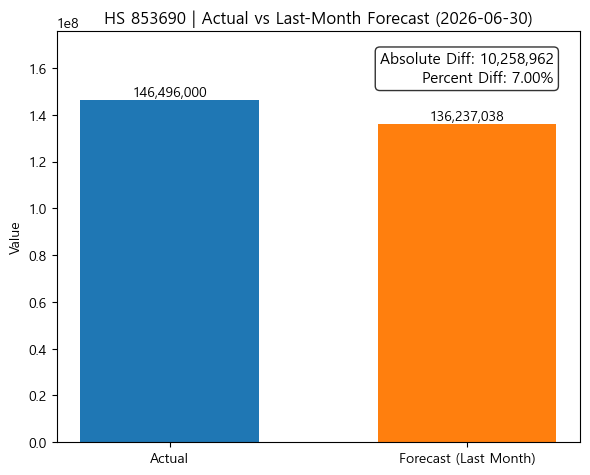

In [32]:
# 전달 예측이 내놓았던 '그 달'의 값과, 이제 확정된 실적을 비교합니다.
common_dates = history_df.index.intersection(last_month_df_filtered.index)
COMPARE_DATE = common_dates.max() if len(common_dates) else LAST_ACTUAL_DATE

actual   = history_df.loc[COMPARE_DATE, TARGET_HSCODE]
forecast = last_month_df_filtered.loc[COMPARE_DATE, TARGET_HSCODE]

abs_diff = abs(actual - forecast)
pct_diff = (abs_diff / actual * 100) if actual else float('nan')

labels = ['Actual', 'Forecast (Last Month)']
values = [actual, forecast]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, values, color=['#1f77b4', '#ff7f0e'], width=0.6)
plt.ylabel('Value')
plt.title(f'HS {TARGET_HSCODE} | Actual vs Last-Month Forecast ({COMPARE_DATE.date()})')
plt.ylim(0, max(values) * 1.2)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f'{h:,.0f}',
             ha='center', va='bottom', fontsize=10)
textstr = f'Absolute Diff: {abs_diff:,.0f}\nPercent Diff: {pct_diff:.2f}%'
plt.text(0.95, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()


## ⑤ 전달 예측 vs 이번달 예측 (전월대비 변화)

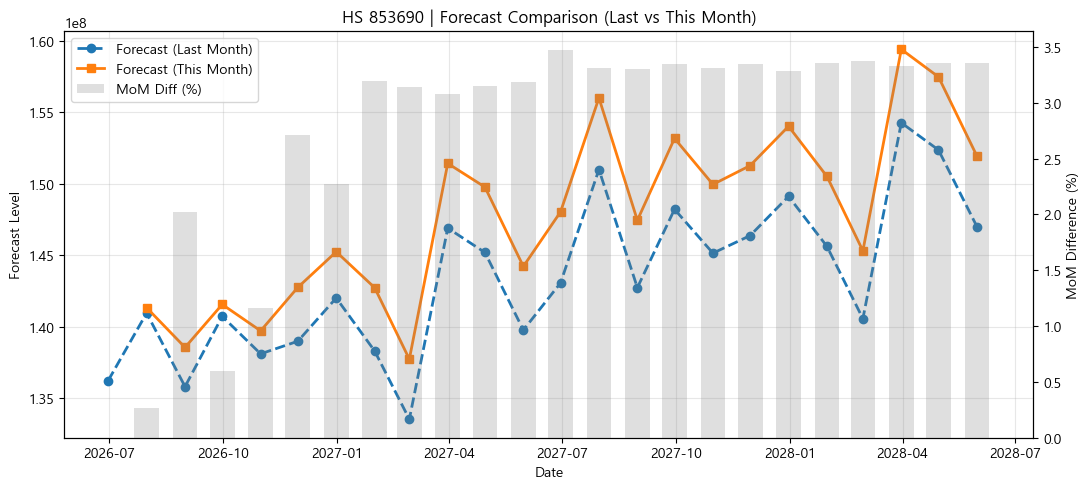

hs_code,Forecast (Last Month),Forecast (This Month),MoM Diff (%)
date,,,
2026-06-30,1.362370e+08,NaN,NaN
2026-07-31,1.409526e+08,1.413283e+08,0.266570
2026-08-31,1.358134e+08,1.385539e+08,2.017843
2026-09-30,1.407210e+08,1.415570e+08,0.594121
2026-10-31,1.381042e+08,1.397103e+08,1.162904
2026-11-30,1.389844e+08,1.427472e+08,2.707353
2026-12-31,1.420081e+08,1.452369e+08,2.273661
2027-01-31,1.383048e+08,1.427275e+08,3.197775
2027-02-28,1.335349e+08,1.377331e+08,3.143899


In [33]:
# FORECAST_START~END 구간에서 전달 예측 대비 이번달 예측이 얼마나 바뀌었는지 비교
last_win = (last_month_df_filtered.loc[FORECAST_START:FORECAST_END, [TARGET_HSCODE]]
            .rename(columns={TARGET_HSCODE: 'Forecast (Last Month)'}).sort_index())
this_win = (this_month_df_filtered.loc[FORECAST_START:FORECAST_END, [TARGET_HSCODE]]
            .rename(columns={TARGET_HSCODE: 'Forecast (This Month)'}).sort_index())

df_plot = last_win.join(this_win, how='outer')
df_plot['MoM Diff (%)'] = (
    (df_plot['Forecast (This Month)'] - df_plot['Forecast (Last Month)'])
    / df_plot['Forecast (Last Month)']
) * 100

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(df_plot.index, df_plot['Forecast (Last Month)'],
         linestyle='--', marker='o', linewidth=2, label='Forecast (Last Month)')
ax1.plot(df_plot.index, df_plot['Forecast (This Month)'],
         linestyle='-', marker='s', linewidth=2, label='Forecast (This Month)')
ax1.set_xlabel('Date'); ax1.set_ylabel('Forecast Level'); ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.bar(df_plot.index, df_plot['MoM Diff (%)'], color='gray', alpha=0.25, width=20,
        label='MoM Diff (%)')
ax2.set_ylabel('MoM Difference (%)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.title(f'HS {TARGET_HSCODE} | Forecast Comparison (Last vs This Month)')
plt.tight_layout(); plt.show()

display(df_plot)


## ⑥ 실적(실선) + 예측(점선) 연속 차트

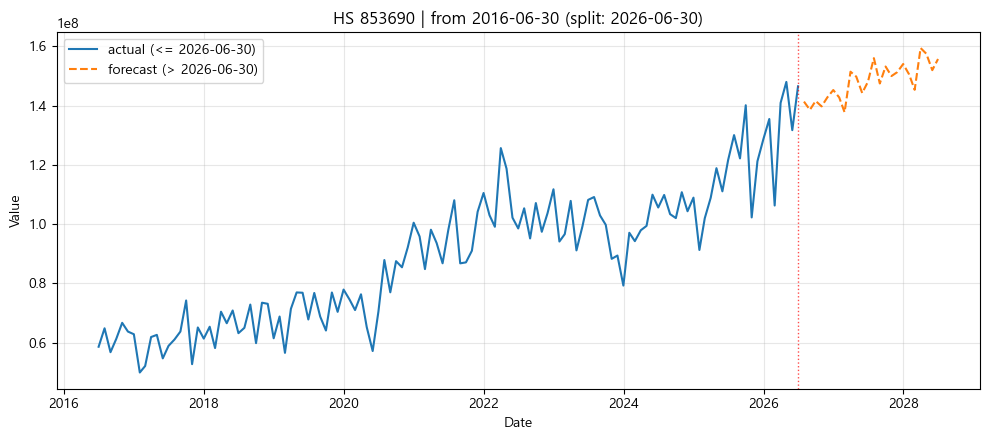

In [34]:
# split_date(=실적 마지막 달)는 ②에서 자동 도출됩니다.
plot_series_split_single_df(
    combined_df=trade_total_df,
    hs_code=TARGET_HSCODE,
    split_date=SPLIT_DATE,
    n_months=HIST_MONTHS,
)


In [35]:
# ============================================================
# HS 코드별 수출 데이터 저장
# ============================================================
from datetime import datetime

# 저장 경로 설정
EXPORT_DIR = r'C:\reports\export_data'

# 폴더가 없으면 자동 생성
os.makedirs(EXPORT_DIR, exist_ok=True)

# 저장 날짜 (파일명용)
today_str = datetime.today().strftime('%Y%m%d')


def save_hscode_data(df, hscode, n_periods=28, save_excel=True, save_csv=True):
    """
    특정 HS 코드의 최근 데이터를 파일로 저장

    Parameters
    ----------
    df : pd.DataFrame
        trade_total_df (컬럼에 HS 코드 포함)
    hscode : str
        저장할 HS 코드 (예: '854232')
    n_periods : int
        저장할 최근 기간 수 (기본 28)
    save_excel : bool
        Excel(.xlsx) 저장 여부
    save_csv : bool
        CSV 저장 여부 (한글 깨짐 방지: utf-8-sig)
    """
    if hscode not in df.columns:
        print(f"[SKIP] {hscode} : 데이터프레임에 존재하지 않는 HS 코드")
        return

    # 최근 n_periods 데이터 추출
    data = df[[hscode]].tail(n_periods).copy()
    data.index.name = 'date'

    # 파일명: hscode_854232_20260703.xlsx 형식
    base_name = f'hscode_{hscode}_{today_str}'

    if save_excel:
        xlsx_path = os.path.join(EXPORT_DIR, base_name + '.xlsx')
        data.to_excel(xlsx_path)
        print(f"[저장 완료] {xlsx_path}")

    if save_csv:
        csv_path = os.path.join(EXPORT_DIR, base_name + '.csv')
        data.to_csv(csv_path, encoding='utf-8-sig')  # 한글 깨짐 방지
        print(f"[저장 완료] {csv_path}")

In [36]:
# ============================================================
# 실행부
# ============================================================

# (1) 단일 HS 코드 저장
save_hscode_data(trade_total_df, TARGET_HSCODE, n_periods=60)

# (2) 여러 HS 코드 일괄 저장이 필요한 경우
# hscode_list = ['854232', '870380', '271012']  # 원하는 코드 목록
# for hs in hscode_list:
#     save_hscode_data(trade_total_df, hs, n_periods=28)

# (3) 데이터프레임 내 모든 HS 코드를 각각 저장하려면
# for hs in trade_total_df.columns:
#     save_hscode_data(trade_total_df, hs, n_periods=28)

[저장 완료] C:\reports\export_data\hscode_853690_20260717.xlsx
[저장 완료] C:\reports\export_data\hscode_853690_20260717.csv


## ⑦ 대상 HS 코드 전체 시계열(실적+예측) 조회

In [37]:
trade_total_df[[TARGET_HSCODE]]

,853690
date,
2007-01-31,7.824390e+06
2007-02-28,7.654930e+06
2007-03-31,9.748920e+06
2007-04-30,8.257640e+06
2007-05-31,9.872060e+06
...,...
2028-02-29,1.453029e+08
2028-03-31,1.593838e+08
2028-04-30,1.574574e+08
